# Startup Success Prediction
## Part 1 — Supervised Learning

This notebook builds a complete supervised learning pipeline to predict startup outcomes
(**IPO**, **Acquisition**, **Failure**) from 10 features describing funding, team, market
and founder profile.

### Dataset
| Property | Value |
|---|---|
| Rows | 100 000 |
| Features | 10 (7 numerical, 3 categorical) |
| Target | `outcome` — 3 classes |
| Missing values | None |

### Notebook structure
1. Exploratory Data Analysis (EDA)
2. Preprocessing — `Pipeline` + `ColumnTransformer`
3. Model Comparison — cross-validation
4. Hyperparameter Tuning — `GridSearchCV`
5. Final Evaluation — confusion matrix, ROC curves, feature importances


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
)
from sklearn.preprocessing import (
    StandardScaler, OrdinalEncoder, FunctionTransformer, label_binarize
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.figsize'] = (10, 6)
print('All libraries imported successfully.')


All libraries imported successfully.


## Step 1 — Exploratory Data Analysis (EDA)

Before building any model we explore the dataset to understand feature distributions,
class balance, correlations, and how categorical features relate to the outcome.

This step is inspired by **TD04** (multi-class analysis) and **TD03** (categorical feature
exploration).


In [2]:
df = pd.read_csv('data/startup_success_dataset.csv')

print(f'Dataset shape : {df.shape}')
print()
print('Data types:')
print(df.dtypes)
print()
print('Missing values:')
print(df.isnull().sum())
print()
print('Outcome classes :', sorted(df['outcome'].unique()))
print('Investor types  :', sorted(df['investor_type'].unique()))
print('Sectors         :', sorted(df['sector'].unique()))
print('Founder profiles:', sorted(df['founder_background'].unique()))

df.head(5)


Dataset shape : (100000, 11)

Data types:
funding_rounds                int64
founder_experience_years      int64
team_size                     int64
market_size_billion         float64
product_traction_users        int64
burn_rate_million           float64
revenue_million             float64
investor_type                   str
sector                          str
founder_background              str
outcome                         str
dtype: object

Missing values:
funding_rounds              0
founder_experience_years    0
team_size                   0
market_size_billion         0
product_traction_users      0
burn_rate_million           0
revenue_million             0
investor_type               0
sector                      0
founder_background          0
outcome                     0
dtype: int64

Outcome classes : ['Acquisition', 'Failure', 'IPO']
Investor types  : ['angel', 'none', 'tier1_vc', 'tier2_vc']
Sectors         : ['AI', 'Climate', 'Crypto', 'Ecommerce', 'Fintech', 'Heal

,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million,investor_type,sector,founder_background,outcome
0,4,13,58,48.225483,594843,18.519211,1.483962e+06,tier2_vc,Health,academic,IPO
1,1,6,221,31.532647,393020,14.298149,8.620568e+05,tier2_vc,Fintech,first_time,Failure
2,3,5,247,4.969722,27636,20.447567,9.726169e+04,none,SaaS,first_time,Failure
3,3,14,229,3.084209,235376,8.177417,1.145785e+06,none,Ecommerce,ex_bigtech,Acquisition
4,1,17,235,13.818188,391765,4.879792,8.608949e+05,none,Health,first_time,Acquisition


In [3]:
print('=== Descriptive Statistics — Numerical Features ===')
df.describe().round(3)


=== Descriptive Statistics — Numerical Features ===


,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million
count,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000
mean,2.002,12.024,150.732,33.204,285422.833,16.776,782819.144
std,1.415,7.208,86.273,43.035,159323.885,15.711,608506.911
min,0.000,0.000,2.000,0.289,668.000,0.280,1344.810
25%,1.000,6.000,76.000,10.197,161194.750,7.088,315486.093
50%,2.000,12.000,151.000,20.158,264989.500,12.169,621362.389
75%,3.000,18.000,226.000,39.532,389214.000,20.954,1098920.637
max,8.000,24.000,299.000,1072.434,915203.000,357.491,4168442.503


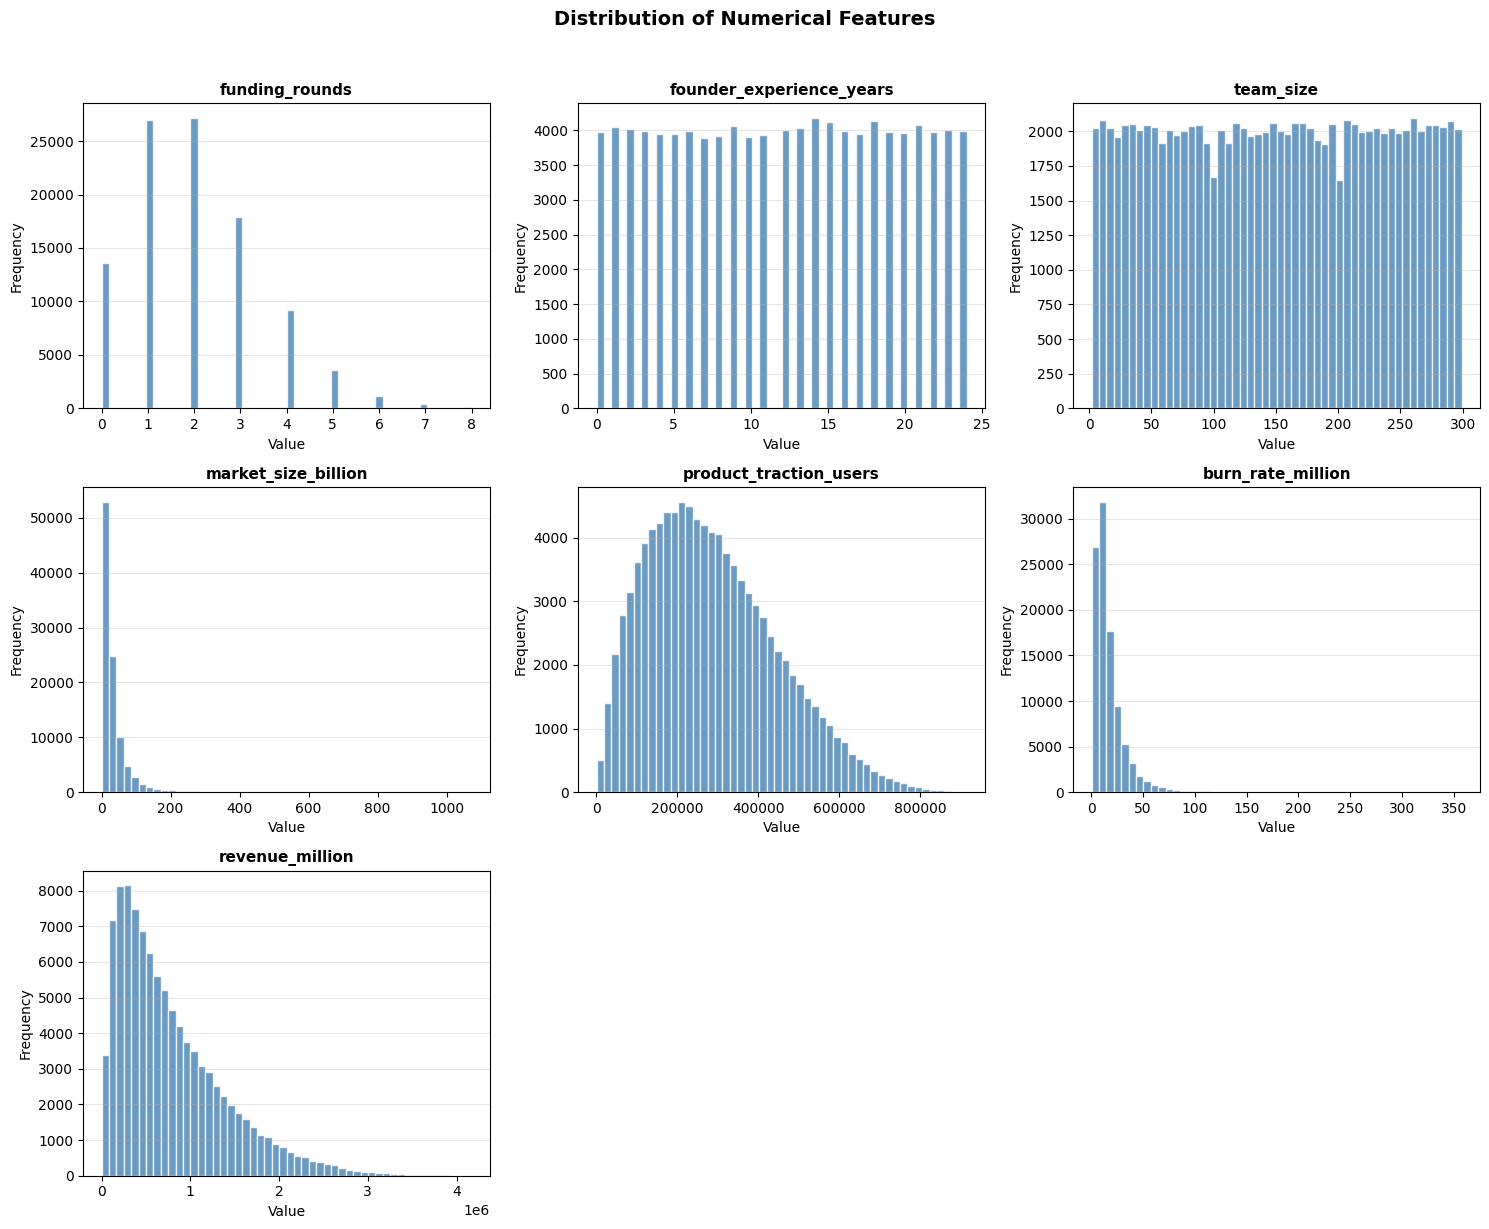

In [4]:
numerical_features = [
    'funding_rounds', 'founder_experience_years', 'team_size',
    'market_size_billion', 'product_traction_users',
    'burn_rate_million', 'revenue_million'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', alpha=0.3)

for j in range(len(numerical_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numerical Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


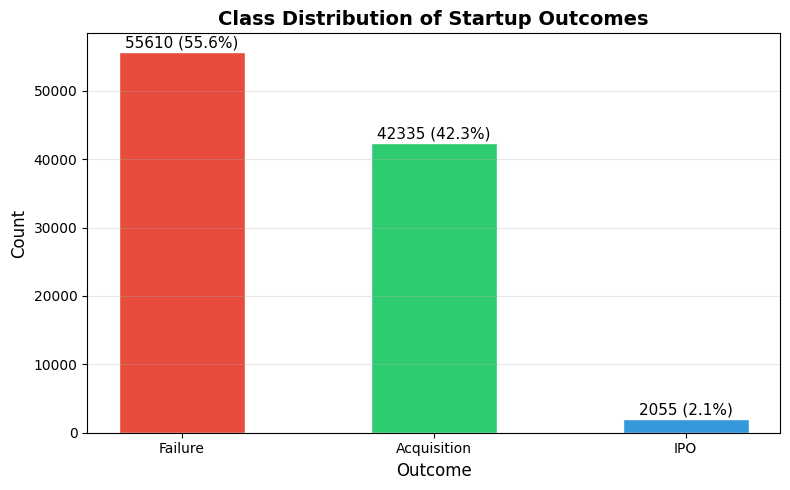

In [5]:
outcome_counts = df['outcome'].value_counts()
bar_colors = ['#e74c3c', '#2ecc71', '#3498db']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(outcome_counts.index, outcome_counts.values,
              color=bar_colors, edgecolor='white', width=0.5)

for bar, count in zip(bars, outcome_counts.values):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 200,
            f'{count} ({pct:.1f}%)', ha='center', va='bottom', fontsize=11)

ax.set_title('Class Distribution of Startup Outcomes', fontsize=14, fontweight='bold')
ax.set_xlabel('Outcome', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


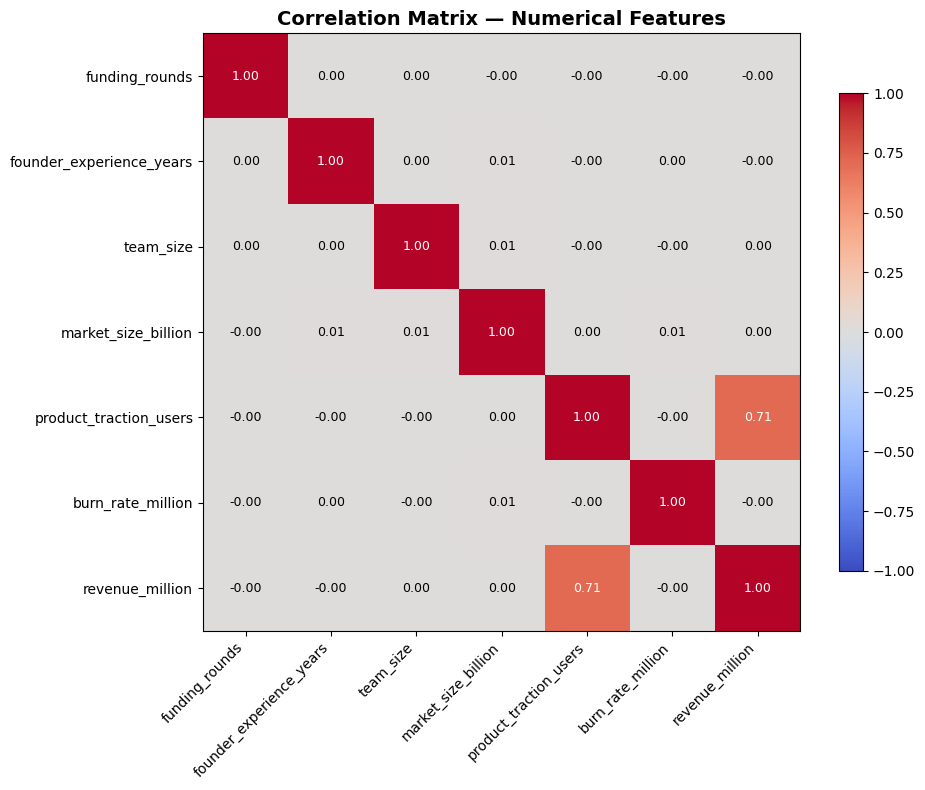

In [6]:
corr = df[numerical_features].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8)

ax.set_xticks(range(len(numerical_features)))
ax.set_yticks(range(len(numerical_features)))
ax.set_xticklabels(numerical_features, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(numerical_features, fontsize=10)

for i in range(len(numerical_features)):
    for j in range(len(numerical_features)):
        val = corr.values[i, j]
        txt_color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color=txt_color)

ax.set_title('Correlation Matrix — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


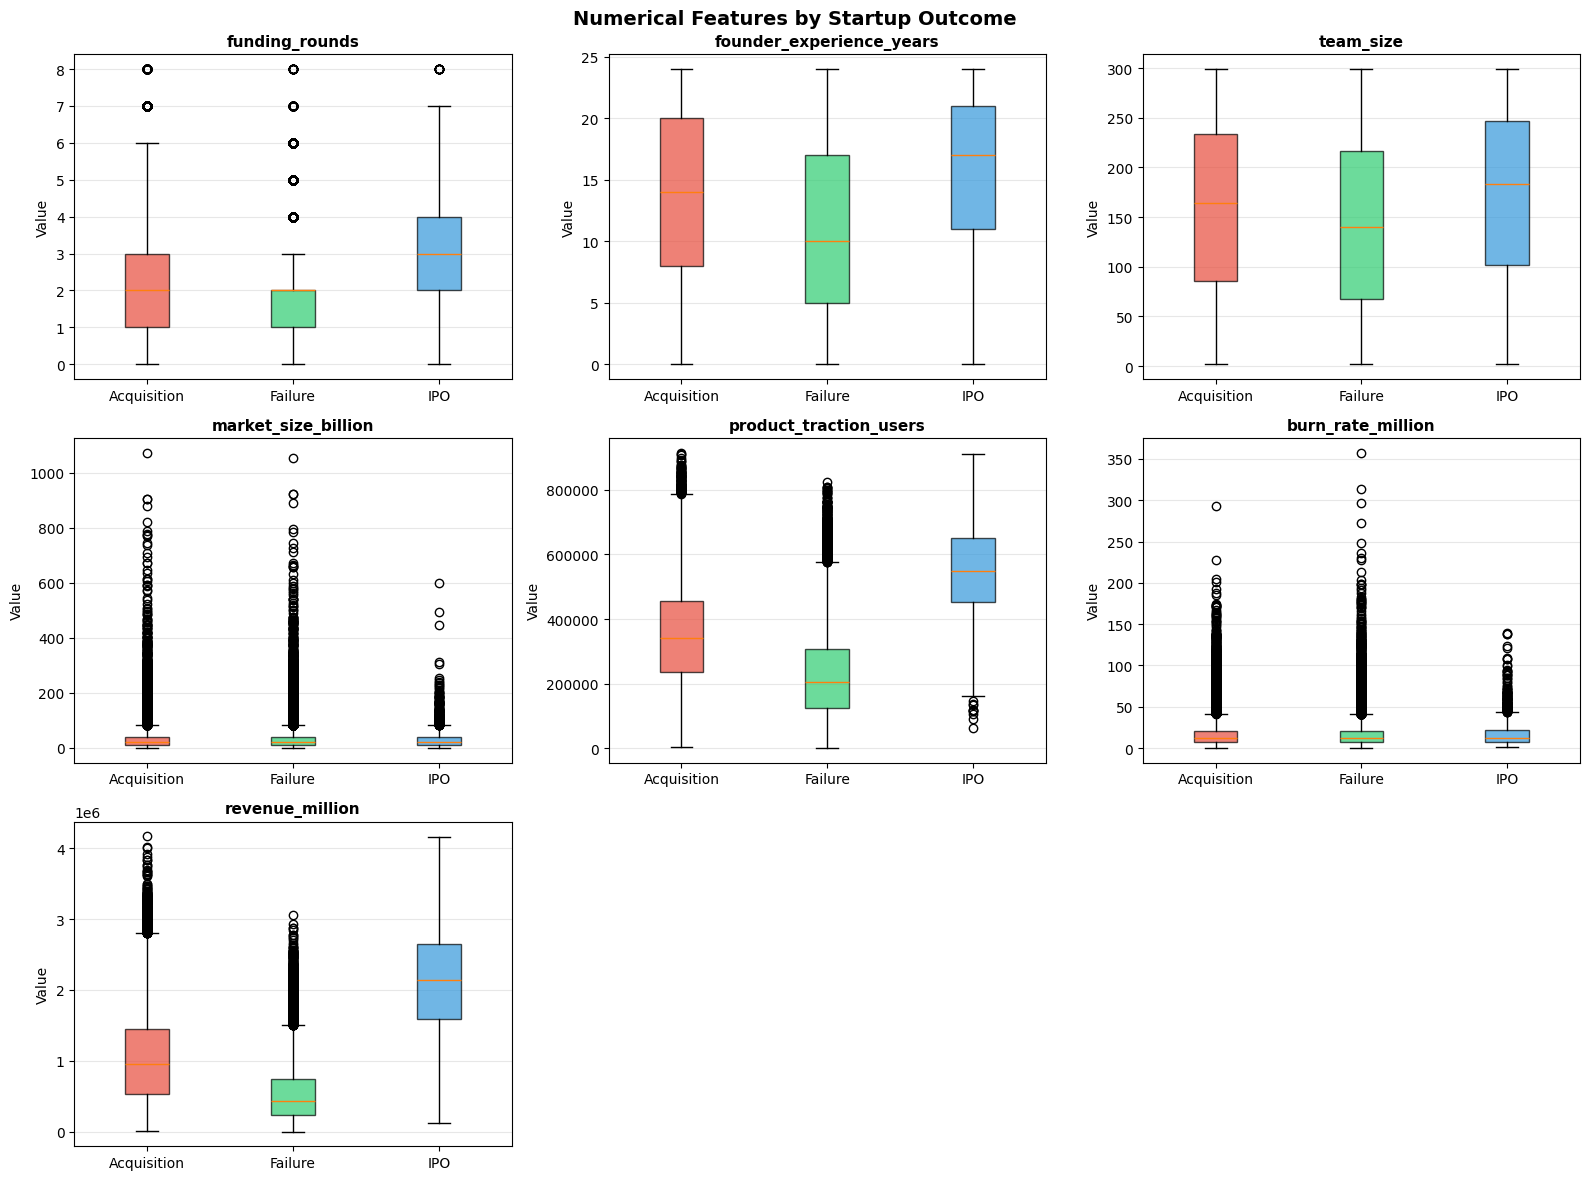

In [7]:
outcomes_list = sorted(df['outcome'].unique().tolist())
palette = dict(zip(outcomes_list, ['#e74c3c', '#2ecc71', '#3498db']))

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    data_groups = [df[df['outcome'] == o][col].values for o in outcomes_list]
    bp = axes[i].boxplot(data_groups, tick_labels=outcomes_list, patch_artist=True)
    for patch, o in zip(bp['boxes'], outcomes_list):
        patch.set_facecolor(palette[o])
        patch.set_alpha(0.7)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].grid(axis='y', alpha=0.3)

for j in range(len(numerical_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features by Startup Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Categorical Feature Analysis (inspired by TD03)

For each categorical feature (`investor_type`, `sector`, `founder_background`) we plot:
- The value count distribution
- The **success rate** per category (IPO + Acquisition = success)

This helps detect which categories are associated with higher startup success before encoding.


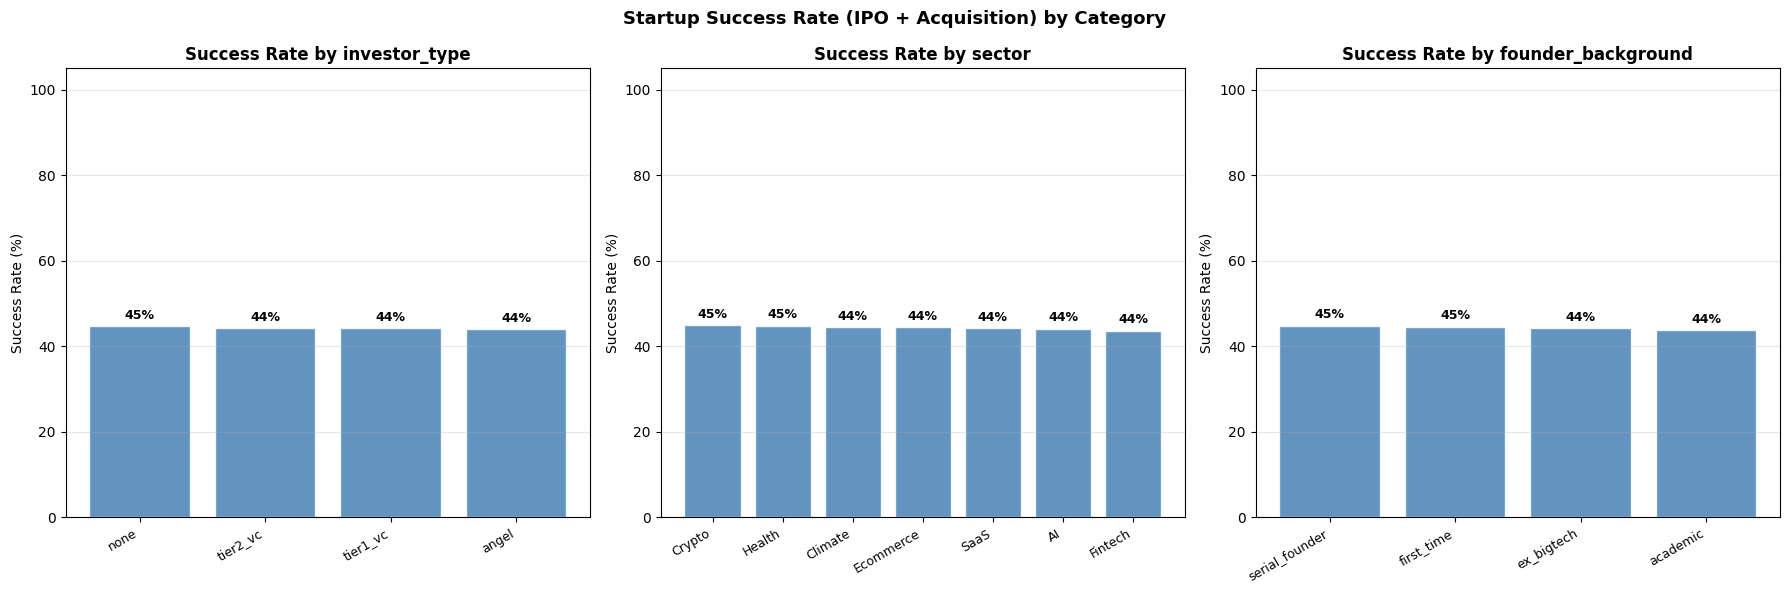

In [8]:
categorical_features = ['investor_type', 'sector', 'founder_background']

# Temporary binary success column (IPO or Acquisition = 1, Failure = 0)
df['is_success'] = df['outcome'].isin(['IPO', 'Acquisition']).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, col in zip(axes, categorical_features):
    stats = (df.groupby(col)['is_success']
               .agg(['count', 'mean'])
               .reset_index()
               .rename(columns={'mean': 'success_rate'})
               .sort_values('success_rate', ascending=False))

    x = range(len(stats))
    bars = ax.bar(x, stats['success_rate'] * 100,
                  color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(stats[col], rotation=30, ha='right', fontsize=9)
    ax.set_title(f'Success Rate by {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Success Rate (%)')
    ax.set_ylim(0, 105)
    ax.grid(axis='y', alpha=0.3)

    for bar, (_, row) in zip(bars, stats.iterrows()):
        ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 1,
                f"{row['success_rate']*100:.0f}%",
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Startup Success Rate (IPO + Acquisition) by Category',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

df.drop(columns=['is_success'], inplace=True)


## Step 2 — Preprocessing

We build a modular preprocessing pipeline using `Pipeline` + `ColumnTransformer`
(as in **TD07**):

- **Numerical features** — `log1p` transform (handle skewness) → `StandardScaler`
- **Categorical features** — `OrdinalEncoder` (converts categories to integers)

The `log1p` transform is applied to all numerical features because some have high
skewness (market_size_billion: 5.26, burn_rate_million: 3.35) and some have zero values,
making `log1p` safer than `log`.


=== Skewness of Numerical Features ===
market_size_billion         5.262
burn_rate_million           3.346
revenue_million             1.255
funding_rounds              0.694
product_traction_users      0.586
team_size                  -0.005
founder_experience_years   -0.009
dtype: float64

Features with |skew| > 1 (benefit from log transform): ['market_size_billion', 'burn_rate_million', 'revenue_million']


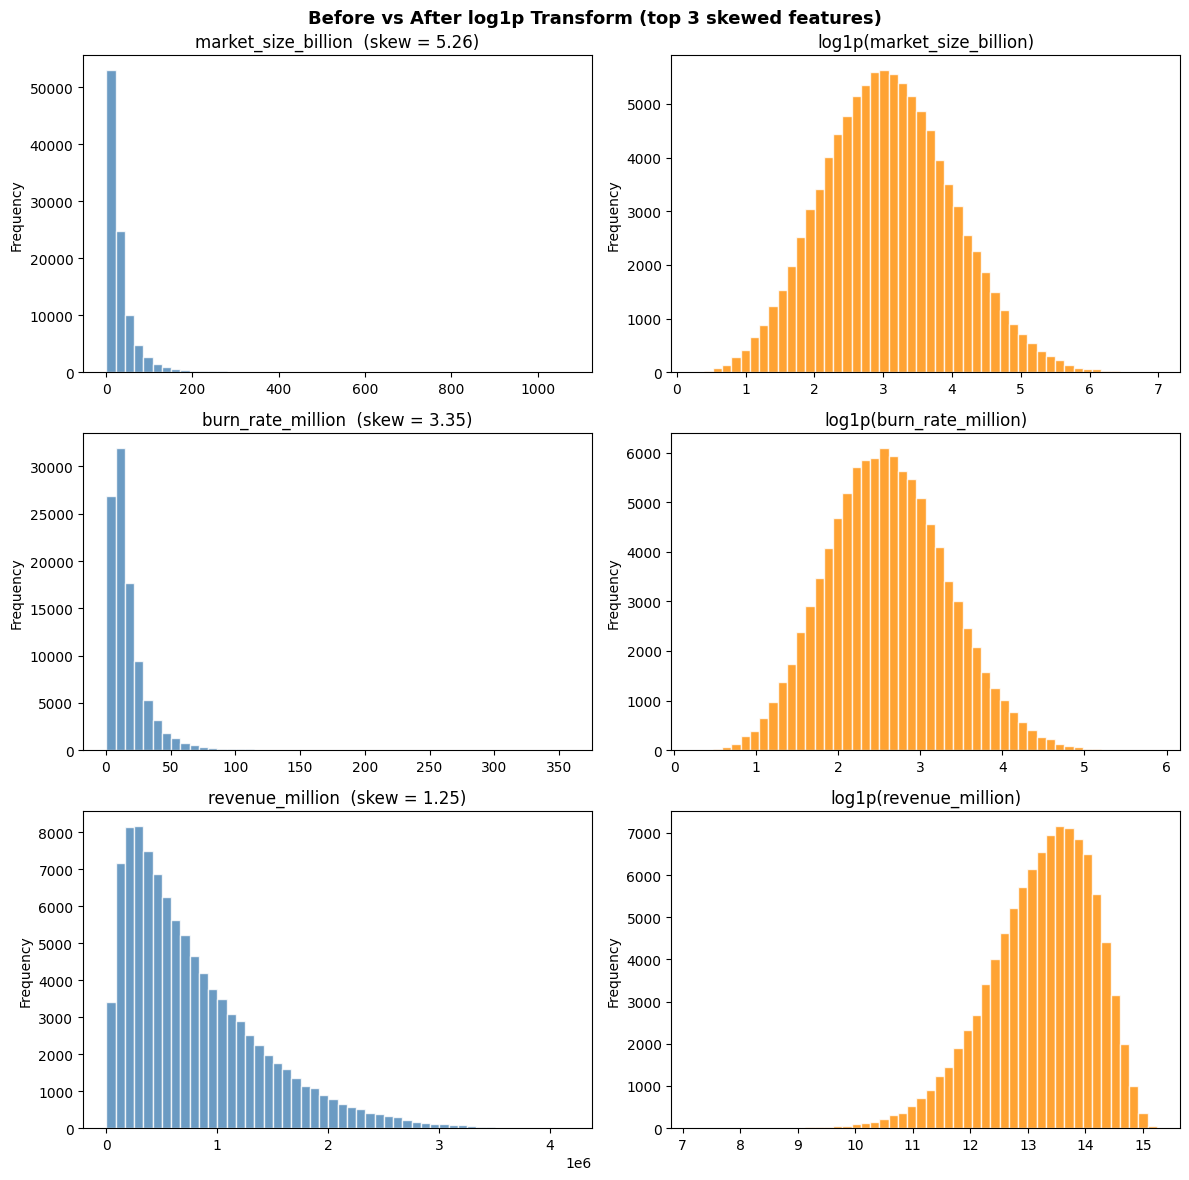

In [9]:
print('=== Skewness of Numerical Features ===')
skewness = df[numerical_features].skew().sort_values(ascending=False)
print(skewness.round(3))

high_skew = skewness[skewness.abs() > 1].index.tolist()
print(f'\nFeatures with |skew| > 1 (benefit from log transform): {high_skew}')

# Visualise before vs after log1p for the top 3 most skewed features
top_skewed = skewness.abs().sort_values(ascending=False).head(3).index.tolist()

fig, axes = plt.subplots(len(top_skewed), 2, figsize=(12, 4 * len(top_skewed)))

for i, col in enumerate(top_skewed):
    axes[i, 0].hist(df[col], bins=50, color='steelblue', alpha=0.8, edgecolor='white')
    axes[i, 0].set_title(f'{col}  (skew = {skewness[col]:.2f})')
    axes[i, 0].set_ylabel('Frequency')

    axes[i, 1].hist(np.log1p(df[col]), bins=50, color='darkorange',
                    alpha=0.8, edgecolor='white')
    axes[i, 1].set_title(f'log1p({col})')
    axes[i, 1].set_ylabel('Frequency')

plt.suptitle('Before vs After log1p Transform (top 3 skewed features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [10]:
# Numerical pipeline: log1p transform → StandardScaler
numerical_pipeline = Pipeline([
    ('log_transform', FunctionTransformer(np.log1p, validate=True)),
    ('scaler', StandardScaler())
])

# Categorical pipeline: OrdinalEncoder
categorical_pipeline = Pipeline([
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# ColumnTransformer applies the right pipeline to the right columns (TD07 pattern)
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

# Feature names after transformation (same order as ColumnTransformer output)
feature_names_all = numerical_features + categorical_features

print('Preprocessor built successfully.')
print(f'  Numerical  ({len(numerical_features)}): {numerical_features}')
print(f'  Categorical ({len(categorical_features)}): {categorical_features}')
print(f'  Total output features: {len(feature_names_all)}')


Preprocessor built successfully.
  Numerical  (7): ['funding_rounds', 'founder_experience_years', 'team_size', 'market_size_billion', 'product_traction_users', 'burn_rate_million', 'revenue_million']
  Categorical (3): ['investor_type', 'sector', 'founder_background']
  Total output features: 10


In [11]:
X = df[numerical_features + categorical_features]
y = df['outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train set : {X_train.shape[0]:,} samples')
print(f'Test set  : {X_test.shape[0]:,} samples')
print()
print('Class distribution — train:')
print(y_train.value_counts(normalize=True).round(4))
print()
print('Class distribution — test:')
print(y_test.value_counts(normalize=True).round(4))


Train set : 80,000 samples
Test set  : 20,000 samples

Class distribution — train:
outcome
Failure        0.5561
Acquisition    0.4234
IPO            0.0206
Name: proportion, dtype: float64

Class distribution — test:
outcome
Failure        0.5561
Acquisition    0.4234
IPO            0.0206
Name: proportion, dtype: float64


## Step 3 — Supervised Learning

We compare four classifiers using 5-fold stratified cross-validation (TD04 approach),
then tune the best candidates with `GridSearchCV` (TD02 / TD07 approach).

| Model | Reference notebook |
|---|---|
| Logistic Regression | TD04 |
| Linear Discriminant Analysis (LDA) | TD04 |
| k-Nearest Neighbours (k-NN) | TD02 |
| Decision Tree | TD07 |


### 3.1 — Initial Model Comparison (Cross-Validation)

Each model is wrapped in a `Pipeline` with the shared preprocessor so that
data leakage is prevented — the scaler is fit only on the training fold.

> **Note on k-NN**: k-NN is a distance-based model that scales poorly with dataset
> size. We evaluate it on a stratified subsample of 10 000 rows to keep runtime
> reasonable, while all other models use the full 80 000-row training set.


In [12]:
models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),
    'LDA': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LinearDiscriminantAnalysis())
    ]),
    'k-NN (k=5)': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier(n_neighbors=5, n_jobs=-1))
    ]),
    'Decision Tree': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE))
    ])
}

print('Model pipelines defined:')
for name in models:
    print(f'  - {name}')


Model pipelines defined:
  - Logistic Regression
  - LDA
  - k-NN (k=5)
  - Decision Tree


In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

# Stratified subsample for k-NN (speed)
rng = np.random.RandomState(RANDOM_STATE)
idx_sample = rng.choice(len(X_train), size=10_000, replace=False)
X_sample = X_train.iloc[idx_sample]
y_sample = y_train.iloc[idx_sample]

for name, pipeline in models.items():
    if 'k-NN' in name:
        scores = cross_val_score(pipeline, X_sample, y_sample,
                                 cv=cv, scoring='accuracy', n_jobs=-1)
        note = '  (10k subsample)'
    else:
        scores = cross_val_score(pipeline, X_train, y_train,
                                 cv=cv, scoring='accuracy', n_jobs=-1)
        note = ''

    cv_results[name] = scores
    print(f'{name:25s}  mean={scores.mean():.4f}  std={scores.std():.4f}{note}')

print()
best_cv_name = max(cv_results, key=lambda k: cv_results[k].mean())
print(f'Best model (CV): {best_cv_name}  ({cv_results[best_cv_name].mean():.4f})')


Logistic Regression        mean=0.7300  std=0.0012


LDA                        mean=0.7258  std=0.0011


k-NN (k=5)                 mean=0.6714  std=0.0124  (10k subsample)


Decision Tree              mean=0.7184  std=0.0026

Best model (CV): Logistic Regression  (0.7300)


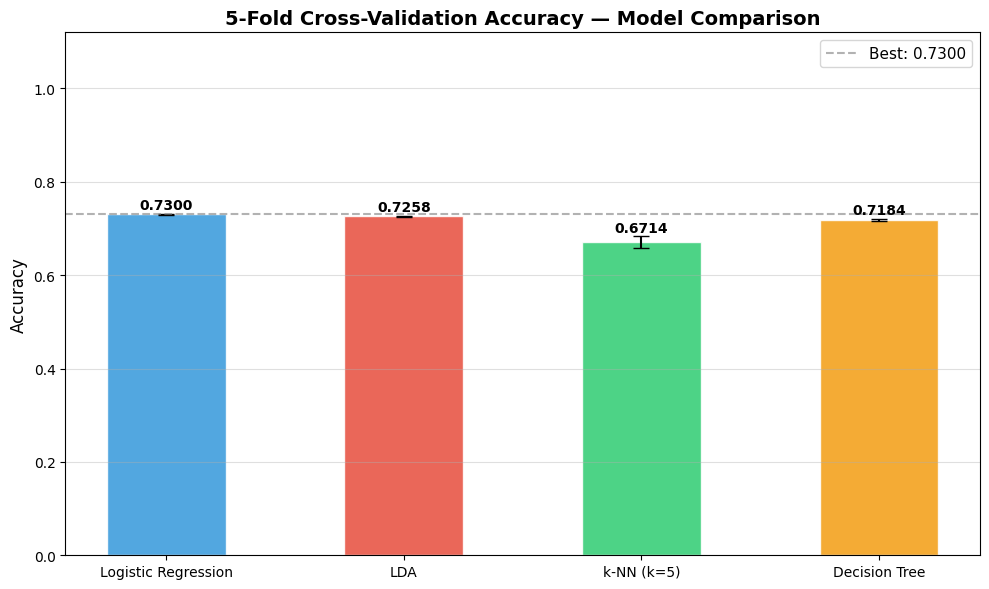

In [14]:
names = list(cv_results.keys())
means = [cv_results[n].mean() for n in names]
stds  = [cv_results[n].std()  for n in names]
colors_cv = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(names, means, yerr=stds, capsize=6,
              color=colors_cv, edgecolor='white', alpha=0.85, width=0.5)

for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2.,
            bar.get_height() + std + 0.003,
            f'{mean:.4f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

ax.set_title('5-Fold Cross-Validation Accuracy — Model Comparison',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_ylim(0, 1.12)
ax.grid(axis='y', alpha=0.4)
ax.axhline(max(means), color='gray', linestyle='--', alpha=0.6,
           label=f'Best: {max(means):.4f}')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


### 3.2 — Hyperparameter Tuning with GridSearchCV

We tune the three most flexible models (TD02 + TD07 approach):

| Model | Parameters tuned |
|---|---|
| **k-NN** | `n_neighbors` ∈ {3, 5, 7, 11, 15, 21} |
| **Decision Tree** | `max_depth` ∈ {5, 10, 15, 20, None} × `min_samples_split` ∈ {2, 10, 50} |
| **Logistic Regression** | `C` ∈ {0.01, 0.1, 1, 10, 100} |

All searches use 5-fold `StratifiedKFold`. k-NN uses the 5 000-row subsample for speed.


In [15]:
# k-NN: 5000-row subsample for speed
rng2 = np.random.RandomState(RANDOM_STATE + 1)
idx_knn = rng2.choice(len(X_train), size=5_000, replace=False)
X_knn, y_knn = X_train.iloc[idx_knn], y_train.iloc[idx_knn]

knn_grid = {'classifier__n_neighbors': [3, 5, 7, 11, 15, 21]}
knn_search = GridSearchCV(
    Pipeline([('preprocessor', preprocessor),
              ('classifier', KNeighborsClassifier(n_jobs=-1))]),
    knn_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='accuracy', n_jobs=-1, verbose=0
)
knn_search.fit(X_knn, y_knn)

best_k = knn_search.best_params_['classifier__n_neighbors']
print(f'k-NN  →  best k = {best_k},  CV accuracy = {knn_search.best_score_:.4f}')


k-NN  →  best k = 21,  CV accuracy = 0.7116


In [16]:
dt_grid = {
    'classifier__max_depth':        [5, 10, 15, 20, None],
    'classifier__min_samples_split': [2, 10, 50]
}
dt_search = GridSearchCV(
    Pipeline([('preprocessor', preprocessor),
              ('classifier', DecisionTreeClassifier(random_state=RANDOM_STATE))]),
    dt_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='accuracy', n_jobs=-1, verbose=0
)
dt_search.fit(X_train, y_train)

print(f'Decision Tree  →  best params = {dt_search.best_params_}')
print(f'               →  CV accuracy = {dt_search.best_score_:.4f}')


Decision Tree  →  best params = {'classifier__max_depth': 10, 'classifier__min_samples_split': 50}
               →  CV accuracy = 0.7198


In [17]:
lr_grid = {'classifier__C': [0.01, 0.1, 1, 10, 100]}
lr_search = GridSearchCV(
    Pipeline([('preprocessor', preprocessor),
              ('classifier', LogisticRegression(max_iter=1000,
                                                random_state=RANDOM_STATE))]),
    lr_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='accuracy', n_jobs=-1, verbose=0
)
lr_search.fit(X_train, y_train)

best_C = lr_search.best_params_['classifier__C']
print(f'Logistic Regression  →  best C = {best_C},  CV accuracy = {lr_search.best_score_:.4f}')


Logistic Regression  →  best C = 1,  CV accuracy = 0.7300


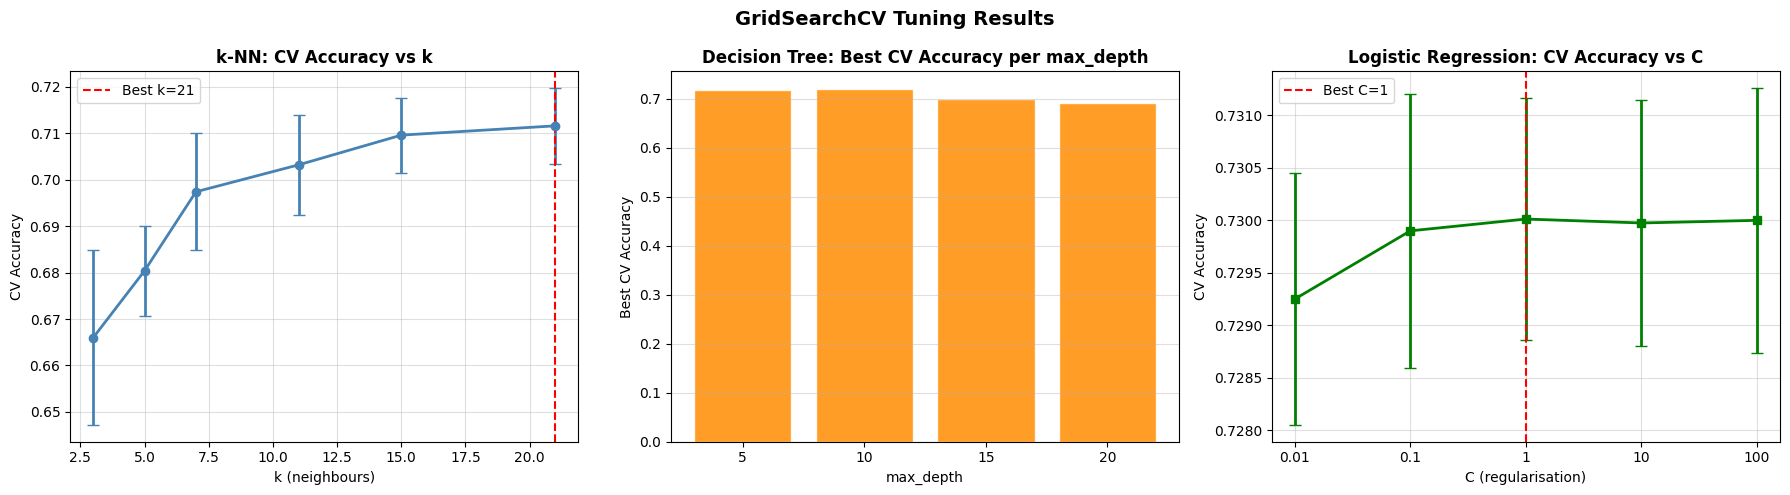

=== GridSearchCV Summary ===
k-NN               : best k=21,  CV=0.7116
Decision Tree      : {'classifier__max_depth': 10, 'classifier__min_samples_split': 50},  CV=0.7198
Logistic Regression: best C=1,  CV=0.7300


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -- k-NN: accuracy vs k --
k_values = knn_grid['classifier__n_neighbors']
knn_means = knn_search.cv_results_['mean_test_score']
knn_stds  = knn_search.cv_results_['std_test_score']
axes[0].errorbar(k_values, knn_means, yerr=knn_stds,
                 marker='o', color='steelblue', linewidth=2, capsize=4)
axes[0].axvline(best_k, color='red', linestyle='--',
                label=f'Best k={best_k}')
axes[0].set_title('k-NN: CV Accuracy vs k', fontsize=12, fontweight='bold')
axes[0].set_xlabel('k (neighbours)')
axes[0].set_ylabel('CV Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.4)

# -- Decision Tree: best CV accuracy per max_depth --
dt_df = pd.DataFrame(dt_search.cv_results_)
depth_agg = (dt_df.groupby('param_classifier__max_depth')['mean_test_score']
                  .max()
                  .reset_index())
depth_labels = [str(d) if d is not None else 'None'
                for d in depth_agg['param_classifier__max_depth']]
axes[1].bar(range(len(depth_agg)), depth_agg['mean_test_score'],
            color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_xticks(range(len(depth_agg)))
axes[1].set_xticklabels(depth_labels)
axes[1].set_title('Decision Tree: Best CV Accuracy per max_depth',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('Best CV Accuracy')
axes[1].grid(axis='y', alpha=0.4)

# -- Logistic Regression: accuracy vs C --
C_values = lr_grid['classifier__C']
lr_means = lr_search.cv_results_['mean_test_score']
lr_stds  = lr_search.cv_results_['std_test_score']
axes[2].errorbar(range(len(C_values)), lr_means, yerr=lr_stds,
                 marker='s', color='green', linewidth=2, capsize=4)
axes[2].set_xticks(range(len(C_values)))
axes[2].set_xticklabels([str(c) for c in C_values])
axes[2].axvline(C_values.index(lr_search.best_params_['classifier__C']),
                color='red', linestyle='--',
                label=f'Best C={lr_search.best_params_["classifier__C"]}')
axes[2].set_title('Logistic Regression: CV Accuracy vs C',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('C (regularisation)')
axes[2].set_ylabel('CV Accuracy')
axes[2].legend()
axes[2].grid(alpha=0.4)

plt.suptitle('GridSearchCV Tuning Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== GridSearchCV Summary ===')
print(f'k-NN               : best k={best_k},  CV={knn_search.best_score_:.4f}')
print(f'Decision Tree      : {dt_search.best_params_},  CV={dt_search.best_score_:.4f}')
print(f'Logistic Regression: best C={lr_search.best_params_["classifier__C"]},  CV={lr_search.best_score_:.4f}')


### 3.3 — Final Evaluation on the Test Set

We select the best model from GridSearchCV and evaluate it on the **held-out test set**
(20 000 samples never seen during training or tuning).

Metrics used (TD04):
- **Confusion Matrix**
- **Classification Report** — precision, recall, F1-score per class
- **ROC Curves** — one-vs-rest for each class (AUC)
- **Feature Importances** — for the Decision Tree model


In [19]:
# Compare tuned models by their GridSearchCV best score
tuned_scores = {
    'Logistic Regression': (lr_search.best_estimator_, lr_search.best_score_),
    'Decision Tree'      : (dt_search.best_estimator_, dt_search.best_score_),
}

best_name     = max(tuned_scores, key=lambda k: tuned_scores[k][1])
best_pipeline = tuned_scores[best_name][0]

print(f'Selected model : {best_name}')
print(f'CV accuracy    : {tuned_scores[best_name][1]:.4f}')

# Predict on the test set
y_pred = best_pipeline.predict(X_test)
test_acc = (y_pred == y_test).mean()
print(f'Test accuracy  : {test_acc:.4f}')

# Class order used by the fitted pipeline
classes = best_pipeline.named_steps['classifier'].classes_.tolist()
print(f'Classes order  : {classes}')


Selected model : Logistic Regression
CV accuracy    : 0.7300
Test accuracy  : 0.7290
Classes order  : ['Acquisition', 'Failure', 'IPO']


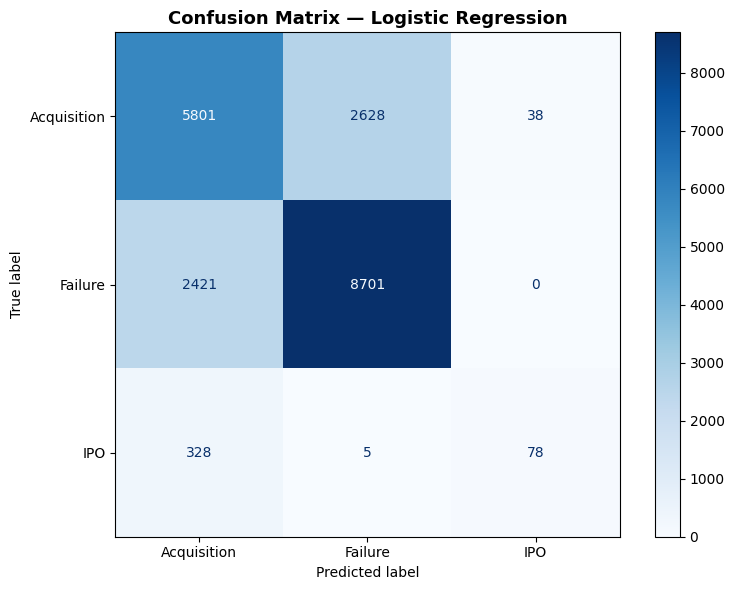

In [20]:
cm   = confusion_matrix(y_test, y_pred, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [21]:
print(f'=== Classification Report — {best_name} ===')
print()
print(classification_report(y_test, y_pred, target_names=classes, digits=4))


=== Classification Report — Logistic Regression ===



              precision    recall  f1-score   support

 Acquisition     0.6785    0.6851    0.6818      8467
     Failure     0.7677    0.7823    0.7749     11122
         IPO     0.6724    0.1898    0.2960       411

    accuracy                         0.7290     20000
   macro avg     0.7062    0.5524    0.5842     20000
weighted avg     0.7280    0.7290    0.7257     20000



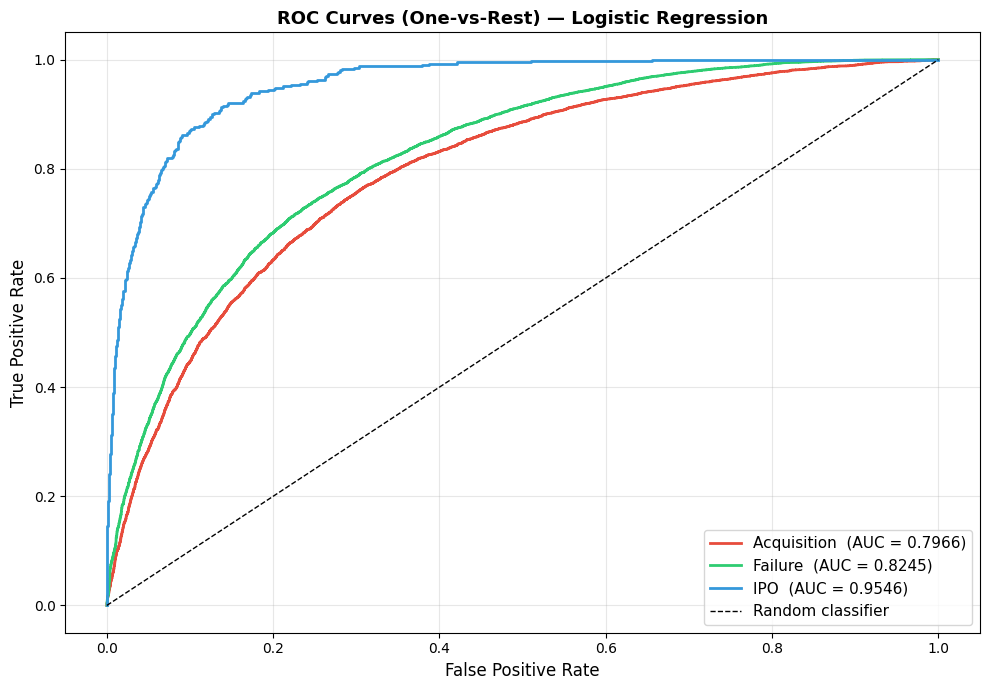

In [22]:
# One-vs-Rest ROC curves for each class (TD04 approach)
y_score    = best_pipeline.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=classes)

colors_roc = ['#e74c3c', '#2ecc71', '#3498db']

fig, ax = plt.subplots(figsize=(10, 7))

for i, (cls, col) in enumerate(zip(classes, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=col, linewidth=2,
            label=f'{cls}  (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'ROC Curves (One-vs-Rest) — {best_name}',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


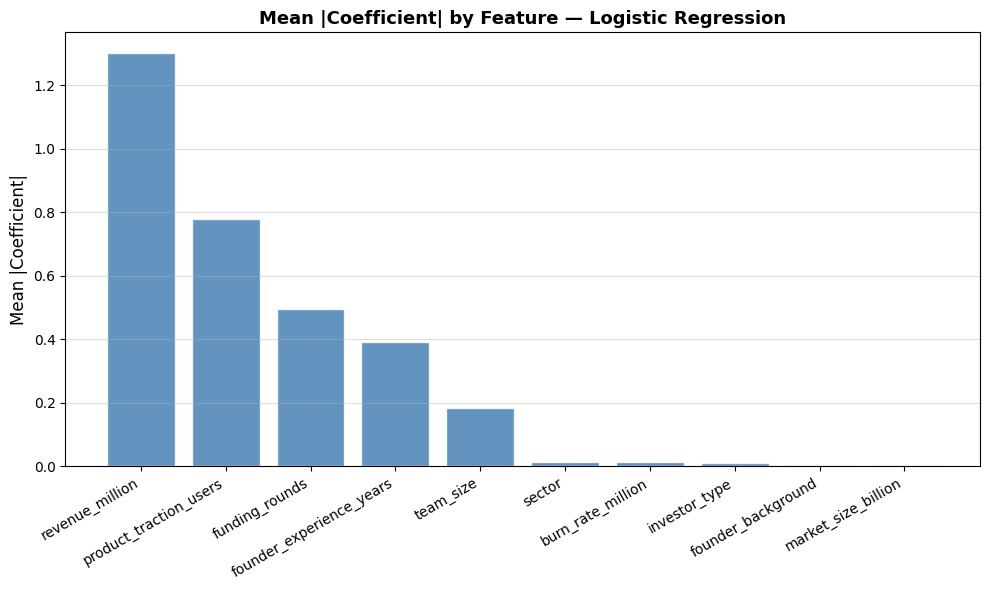

In [23]:
if hasattr(best_pipeline.named_steps['classifier'], 'feature_importances_'):
    importances = best_pipeline.named_steps['classifier'].feature_importances_
    sorted_idx   = np.argsort(importances)[::-1]
    sorted_names = [feature_names_all[i] for i in sorted_idx]
    sorted_imp   = importances[sorted_idx]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(range(len(sorted_imp)), sorted_imp,
           color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_xticks(range(len(sorted_names)))
    ax.set_xticklabels(sorted_names, rotation=30, ha='right', fontsize=10)
    ax.set_title(f'Feature Importances — {best_name}',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('Importance', fontsize=12)
    ax.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    plt.show()

    print('Top 3 most important features:')
    for i in range(min(3, len(sorted_names))):
        print(f'  {i+1}. {sorted_names[i]:35s} {sorted_imp[i]:.4f}')

elif hasattr(best_pipeline.named_steps['classifier'], 'coef_'):
    # Logistic Regression: show coefficient magnitudes per class
    coef = np.abs(best_pipeline.named_steps['classifier'].coef_)
    mean_imp = coef.mean(axis=0)
    sorted_idx   = np.argsort(mean_imp)[::-1]
    sorted_names = [feature_names_all[i] for i in sorted_idx]
    sorted_imp   = mean_imp[sorted_idx]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(range(len(sorted_imp)), sorted_imp,
           color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_xticks(range(len(sorted_names)))
    ax.set_xticklabels(sorted_names, rotation=30, ha='right', fontsize=10)
    ax.set_title(f'Mean |Coefficient| by Feature — {best_name}',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('Mean |Coefficient|', fontsize=12)
    ax.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    plt.show()
else:
    print(f'Feature importances not available for {best_name}.')


## Conclusion — Supervised Learning

### Pipeline summary
| Step | Method | Reference |
|---|---|---|
| Log transform + StandardScaler | `FunctionTransformer` + `StandardScaler` | TD07, TD10 |
| Categorical encoding | `OrdinalEncoder` in `ColumnTransformer` | TD03, TD07 |
| Model comparison | 5-fold `cross_val_score` | TD04 |
| Hyperparameter tuning | `GridSearchCV` | TD02, TD07 |
| Evaluation | Confusion matrix, ROC-AUC, F1 | TD04 |

### Key takeaways
- Wrapping preprocessing inside `Pipeline` ensures no data leakage between folds.
- `GridSearchCV` with `StratifiedKFold` guarantees class balance in every fold.
- The ROC curves (One-vs-Rest) allow per-class analysis even for a 3-class problem.
- Feature importances (Decision Tree) or coefficient magnitudes (Logistic Regression)
  reveal which variables drive startup success predictions the most.

### Next step
**Part 2 — Unsupervised Learning**: k-Means clustering and Hierarchical clustering
to discover natural groupings of startups without using the outcome label.
